<a href="https://colab.research.google.com/github/hitJangra/Microsoft-Stock-Predictor-LSTM/blob/main/LSTM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

In [7]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

## loading the data

In [8]:
data = pd.read_csv("MicrosoftStock.csv")
print(data.head())
print(data.info())
print(data.describe())

    index        date   open   high    low  close    volume  Name
0  390198  2013-02-08  27.35  27.71  27.31  27.55  33318306  MSFT
1  390199  2013-02-11  27.65  27.92  27.50  27.86  32247549  MSFT
2  390200  2013-02-12  27.88  28.00  27.75  27.88  35990829  MSFT
3  390201  2013-02-13  27.93  28.11  27.88  28.03  41715530  MSFT
4  390202  2013-02-14  27.92  28.06  27.87  28.04  32663174  MSFT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB
None
               index         open         high          low 

## Initial data visualisation

### Plot 1 - Open & close prices

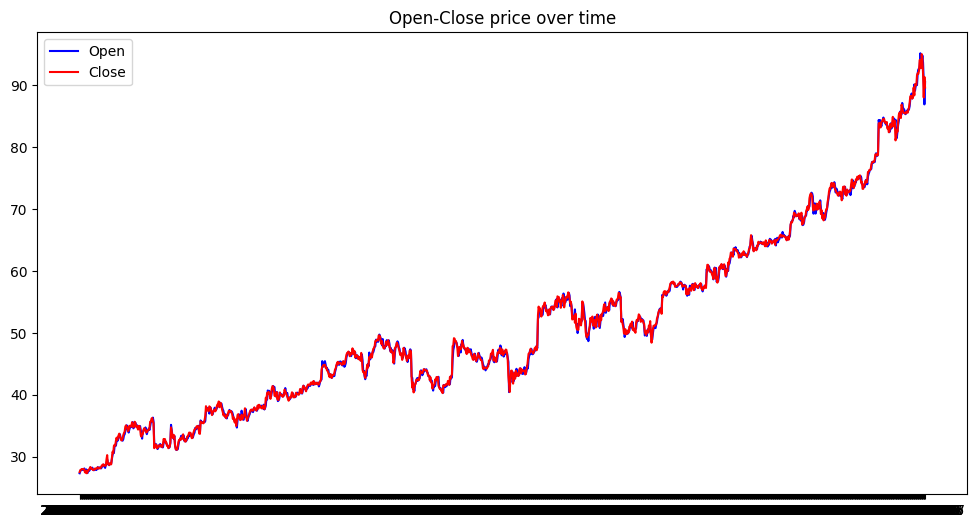

In [9]:
plt.figure(figsize = (12, 6))
plt.plot(data['date'], data['open'], label = "Open", color = "blue")
plt.plot(data['date'], data['close'], label = "Close", color = "red")
plt.title("Open-Close price over time")
plt.legend()
plt.show()

### Plot 2 - Trading volume (checking for outliers)

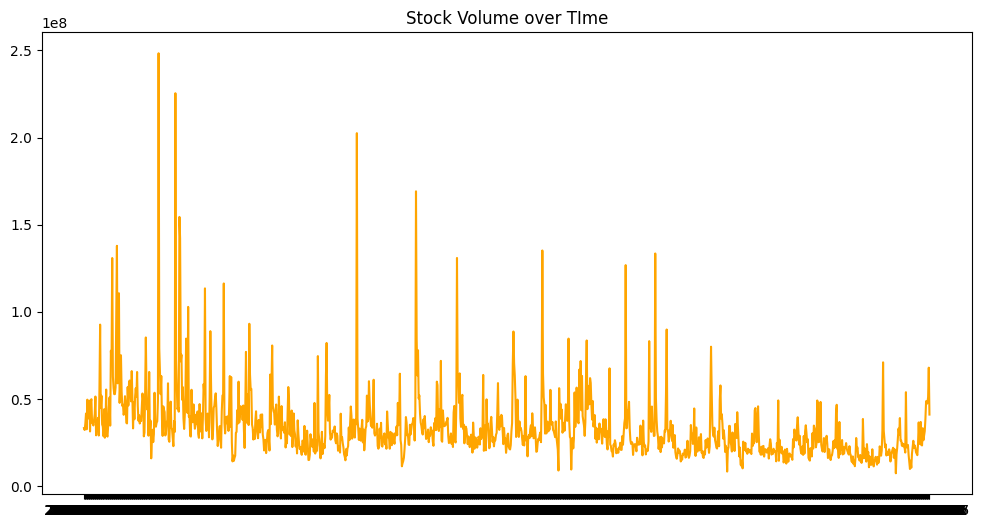

In [10]:
plt.figure(figsize = (12, 6))
plt.plot(data['date'], data['volume'], label = "Volume", color = "orange")
plt.title("Stock Volume over TIme")
plt.show()

## Dropping non-numeric data

In [11]:
numeric_data = data.select_dtypes(include=["int64", "float64"])

### Plot 3 - Checking correlation between features

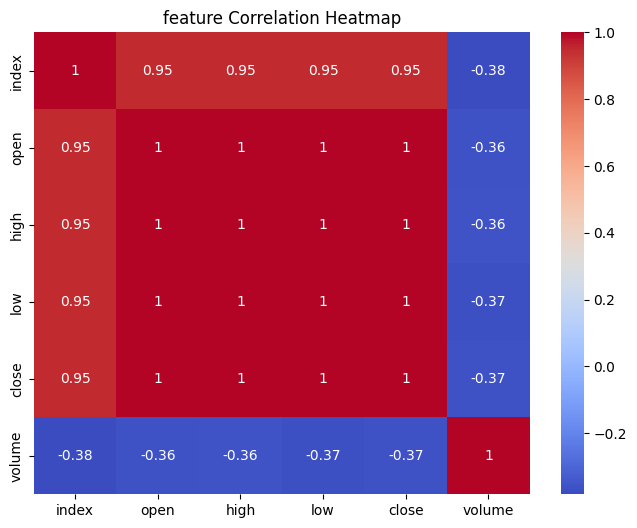

In [12]:
plt.figure(figsize= [8, 6])
sns.heatmap(numeric_data.corr(), annot = True, cmap="coolwarm")
plt.title("feature Correlation Heatmap")
plt.show()

## Converting the date into datetime & then creating a date filter

In [13]:
data['date'] = pd.to_datetime(data['date'])

In [14]:
prediction = data.loc[
    (data['date'] > datetime(2013, 1, 1)) &
    (data['date'] < datetime(2018, 1, 1))
]

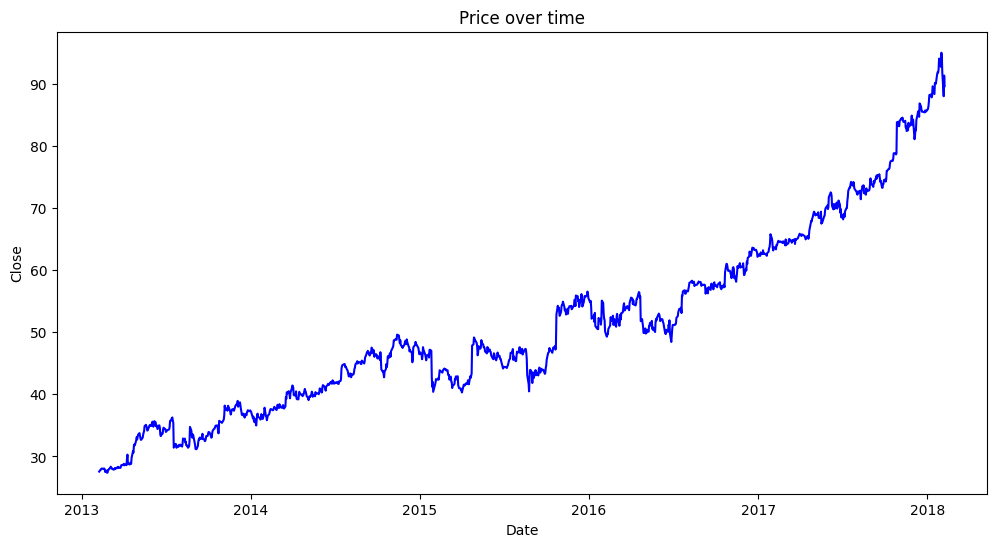

In [15]:
plt.figure(figsize = (12, 6))
plt.plot(data['date'], data['close'], color = "blue")
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Price over time")
plt.show()

## Preparing for the LSTM Model (Sequential)

In [16]:
stock_close = data.filter(["close"])
dataset = stock_close.values  # convert to numpy array

In [17]:
dataset_train, dataset_test = train_test_split(
    dataset, test_size=0.05, shuffle=False
)
training_data_len = len(dataset_train)

# preprocessing stages

In [18]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

training_data = scaled_data[:training_data_len]  # 95% of all our data

X_train, y_train = [], []

### Creating a sliding window for our stock (60 days)

In [19]:
for i in range(60, len(training_data)):
    X_train.append(training_data[i - 60:i, 0])
    y_train.append(training_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

## Building the model

In [20]:
model = keras.models.Sequential()

In [21]:
# First Layer
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
# Second Layer
model.add(keras.layers.LSTM(64, return_sequences=False))
# 3rd Layer (Dense)
model.add(keras.layers.Dense(128, activation="relu"))
# 4th Layer (Dropout)
model.add(keras.layers.Dropout(0.5))
# Final Output Layer
model.add(keras.layers.Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.summary()
model.compile(
    optimizer="adam",
    loss="mae",
    metrics=[keras.metrics.RootMeanSquaredError()]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
training = model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2313 - root_mean_squared_error: 0.3279
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1302 - root_mean_squared_error: 0.1760
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1260 - root_mean_squared_error: 0.1722
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1217 - root_mean_squared_error: 0.1641
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1168 - root_mean_squared_error: 0.1605
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1100 - root_mean_squared_error: 0.1513
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1113 - root_mean_squared_error: 0.1502
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1077 - root_mean_squared_error: 0.1488
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1061 - root_mean_squared_error: 0.1452
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1035 - root_mean_squared_error: 0.1404

In [25]:
# Prep the test data
test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]

for i in range(60, len(test_data)):
    X_test.append(test_data[i - 60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [26]:
# Make a Prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 349ms/step


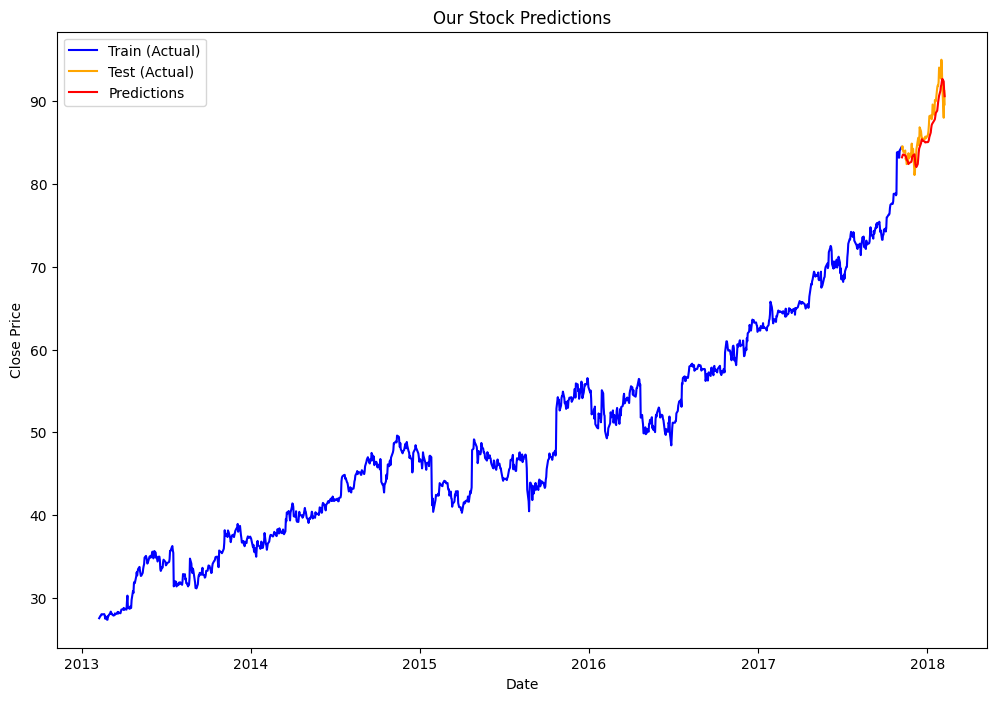

In [27]:
# Plotting data
train = data[:training_data_len]
test = data[training_data_len:].copy()
test['Predictions'] = predictions

plt.figure(figsize=(12, 8))
plt.plot(train['date'], train['close'], label="Train (Actual)", color='blue')
plt.plot(test['date'], test['close'], label="Test (Actual)", color='orange')
plt.plot(test['date'], test['Predictions'], label="Predictions", color='red')
plt.title("Our Stock Predictions")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()